# Notebook 03 — Exploratory Data Analysis

Analyses both datasets to surface patterns before modelling:
- Full time series visualisation
- Seasonal decomposition (trend / seasonal / residual)
- Hourly, daily, monthly, seasonal usage patterns
- Heatmaps (hour × day-of-week)
- Rolling statistics & peak-period analysis
- Autocorrelation (ACF / PACF)
- Multi-feature correlation (UCI)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

PROC = os.path.join('..', 'data', 'processed')
FIGS = os.path.join('..', 'notebooks', 'figures')
os.makedirs(FIGS, exist_ok=True)

pjm = pd.read_csv(os.path.join(PROC, 'pjm_processed.csv'),
                  index_col='Datetime', parse_dates=True)
uci = pd.read_csv(os.path.join(PROC, 'uci_processed.csv'),
                  index_col='Datetime', parse_dates=True)

print(f'PJM shape : {pjm.shape}  |  {pjm.index[0].date()} to {pjm.index[-1].date()}')
print(f'UCI shape : {uci.shape}  |  {uci.index[0].date()} to {uci.index[-1].date()}')

PJM shape : (145392, 9)  |  2002-01-01 to 2018-08-03
UCI shape : (34589, 15)  |  2006-12-16 to 2010-11-26


---
## Part 1 — PJM East Dataset

In [2]:
print('=== PJM East — Basic Statistics ===\n')
print(pjm[['PJME_MW']].describe().round(2).to_string())
print(f'\nYears covered : {sorted(pjm.index.year.unique().tolist())}')
print(f'Total records : {len(pjm):,} hourly readings')

=== PJM East — Basic Statistics ===

         PJME_MW
count  145392.00
mean    31997.82
std      6226.76
min     15456.62
25%     27571.00
50%     31420.00
75%     35647.25
max     47761.62

Years covered : [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
Total records : 145,392 hourly readings


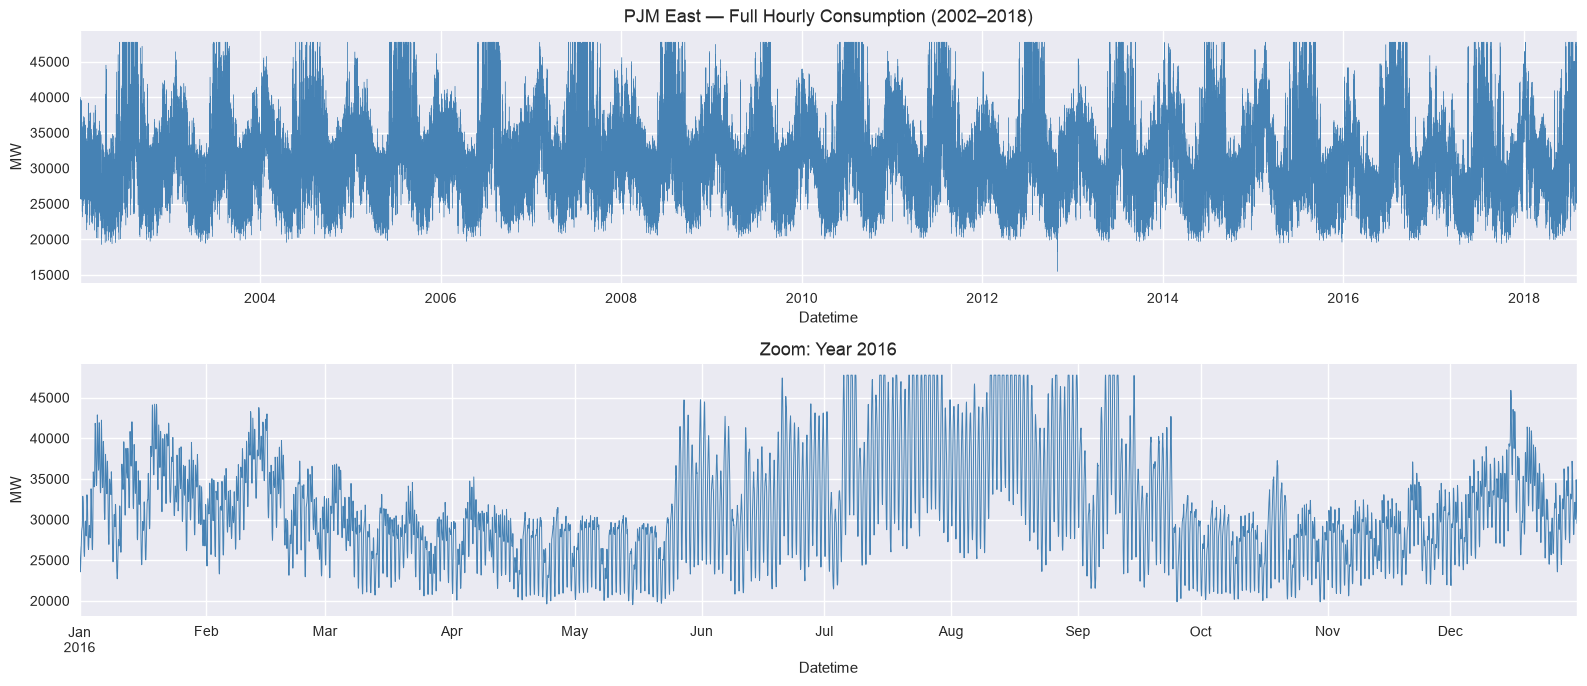

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7))

pjm['PJME_MW'].plot(ax=axes[0], lw=0.3, color='steelblue')
axes[0].set_title('PJM East — Full Hourly Consumption (2002–2018)', fontsize=13)
axes[0].set_ylabel('MW')

pjm.loc['2016', 'PJME_MW'].plot(ax=axes[1], lw=0.7, color='steelblue')
axes[1].set_title('Zoom: Year 2016', fontsize=13)
axes[1].set_ylabel('MW')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_timeseries.png'), bbox_inches='tight', dpi=120)
plt.show()

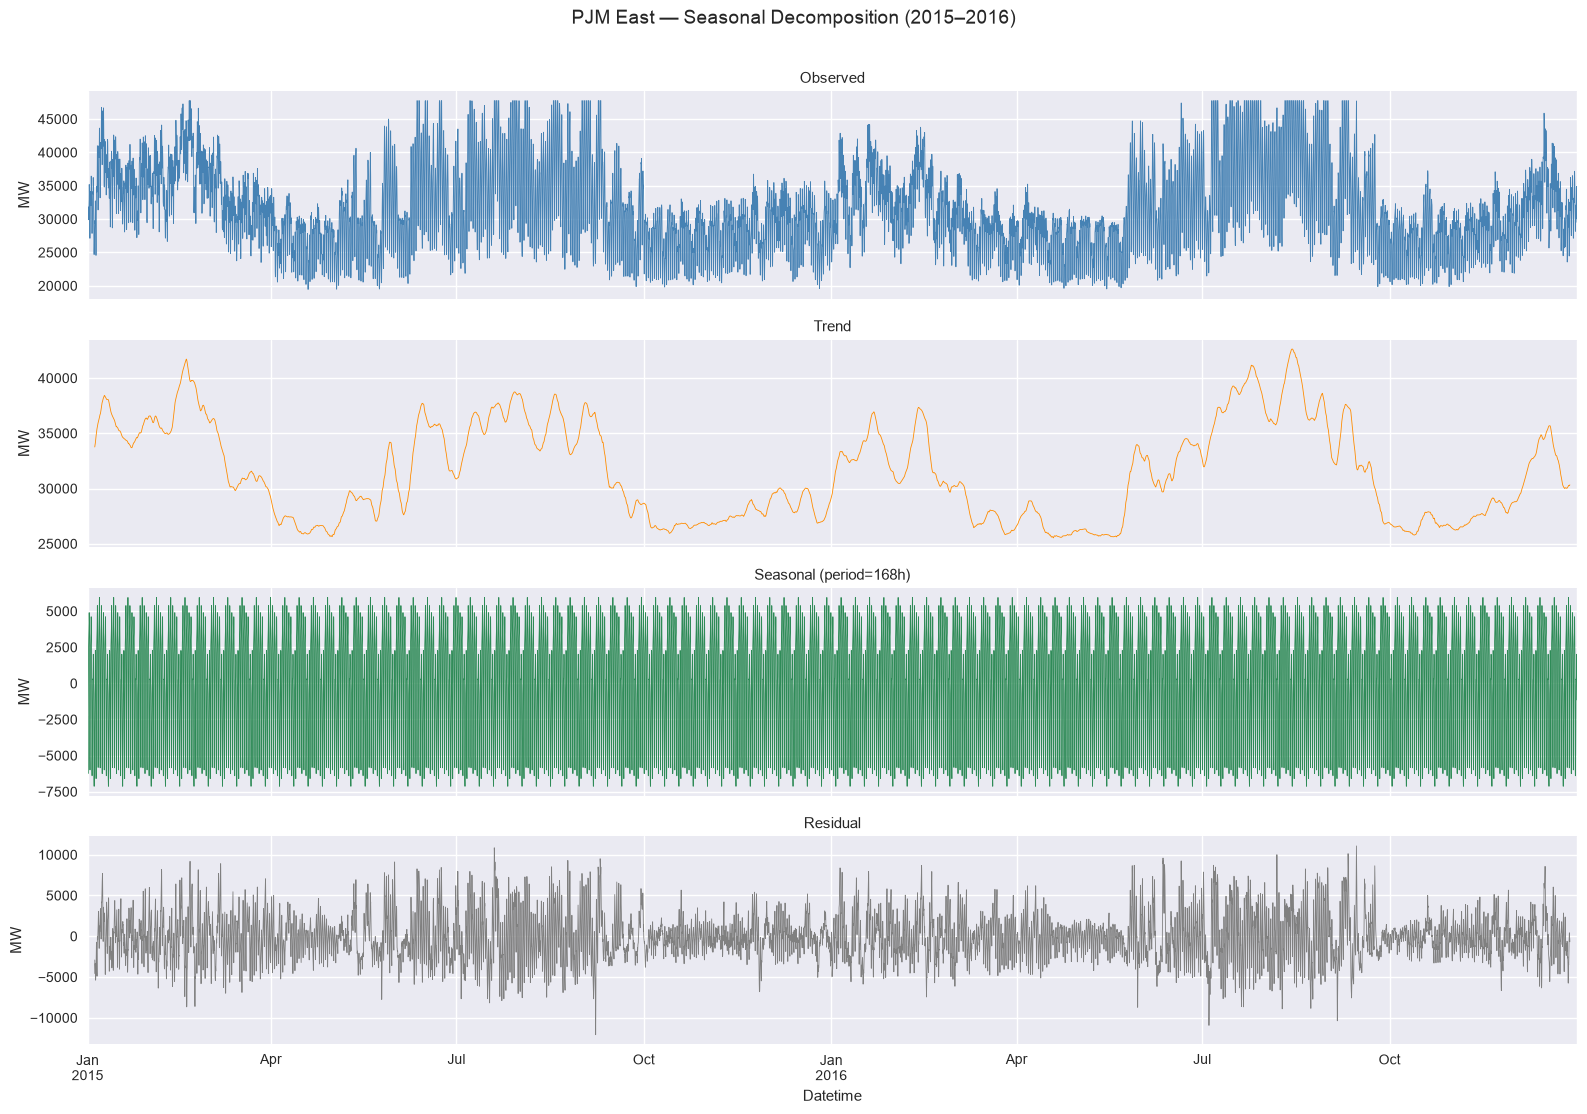

In [4]:
# Seasonal decomposition on 2-year subset (weekly seasonality period=168h)
pjm_sub = pjm.loc['2015':'2016', 'PJME_MW']
decomp = seasonal_decompose(pjm_sub, model='additive', period=24 * 7)

fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
components = [
    (decomp.observed, 'Observed',              'steelblue'),
    (decomp.trend,    'Trend',                 'darkorange'),
    (decomp.seasonal, 'Seasonal (period=168h)','seagreen'),
    (decomp.resid,    'Residual',              'gray'),
]
for ax, (series, title, colour) in zip(axes, components):
    series.plot(ax=ax, lw=0.6, color=colour)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('MW')

fig.suptitle('PJM East — Seasonal Decomposition (2015–2016)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_decomposition.png'), bbox_inches='tight', dpi=120)
plt.show()

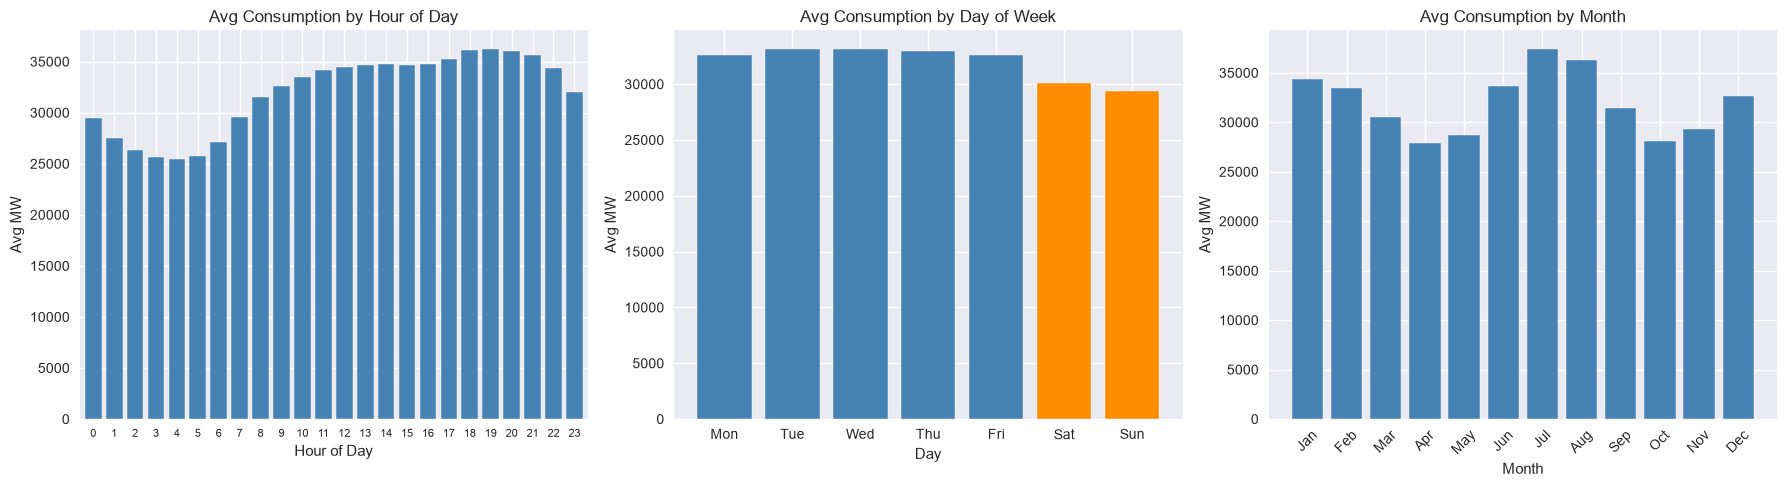


Average by season:
  Winter  : 33,502.7 MW
  Spring  : 29,033.1 MW
  Summer  : 35,805.9 MW
  Autumn  : 29,614.1 MW


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly pattern
hourly = pjm.groupby('hour')['PJME_MW'].mean()
hourly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white', width=0.8)
axes[0].set_title('Avg Consumption by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg MW')
axes[0].set_xticklabels(range(24), rotation=0, fontsize=8)

# Day-of-week pattern
days  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = pjm.groupby('day_of_week')['PJME_MW'].mean()
colours = ['steelblue'] * 5 + ['darkorange'] * 2
axes[1].bar(days, daily.values, color=colours, edgecolor='white')
axes[1].set_title('Avg Consumption by Day of Week', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg MW')

# Monthly pattern
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = pjm.groupby('month')['PJME_MW'].mean()
axes[2].bar(months, monthly.values, color='steelblue', edgecolor='white')
axes[2].set_title('Avg Consumption by Month', fontsize=12)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg MW')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_patterns.png'), bbox_inches='tight', dpi=120)
plt.show()

seasons = {0:'Winter',1:'Spring',2:'Summer',3:'Autumn'}
print('\nAverage by season:')
for k, v in seasons.items():
    val = pjm[pjm['season'] == k]['PJME_MW'].mean()
    print(f'  {v:7s} : {val:,.1f} MW')

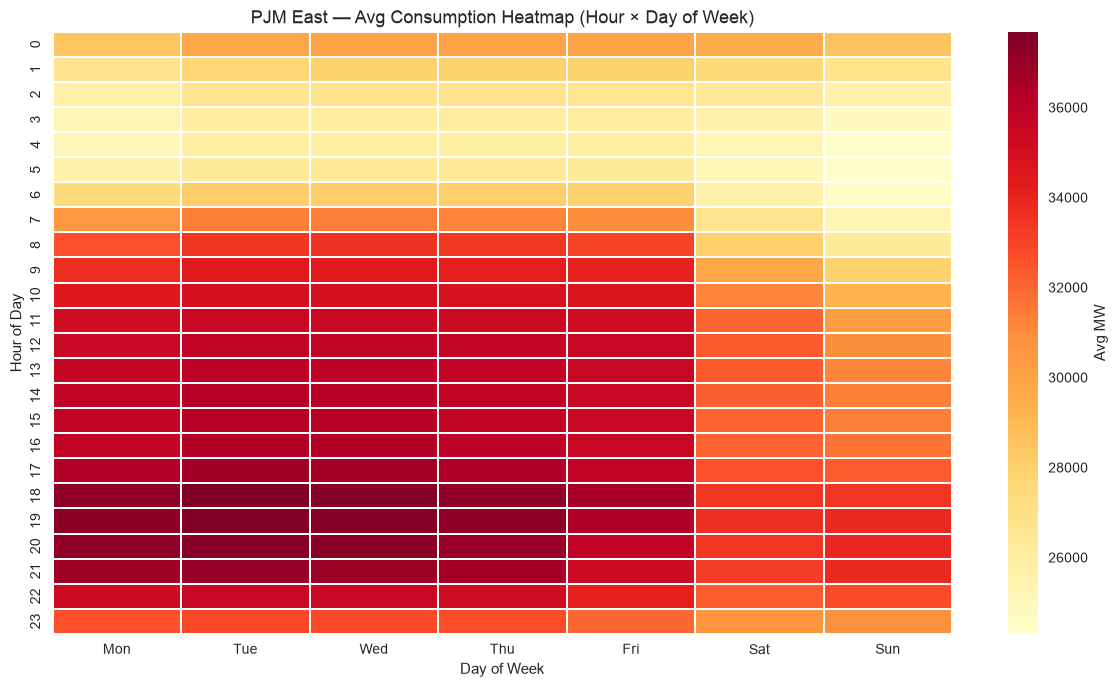

Peak demand  : 37,686.0 MW  at hour 19:00 on Tue
Lowest avg   : 24,300.4 MW  at hour 05:00 on Sun


In [6]:
pivot = pjm.pivot_table(values='PJME_MW', index='hour',
                        columns='day_of_week', aggfunc='mean')
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg MW'})
plt.title('PJM East — Avg Consumption Heatmap (Hour × Day of Week)', fontsize=13)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_heatmap.png'), bbox_inches='tight', dpi=120)
plt.show()

peak_idx = pivot.stack().idxmax()
print(f'Peak demand  : {pivot.stack().max():,.1f} MW  at hour {peak_idx[0]:02d}:00 on {peak_idx[1]}')
print(f'Lowest avg   : {pivot.stack().min():,.1f} MW  at hour {pivot.stack().idxmin()[0]:02d}:00 on {pivot.stack().idxmin()[1]}')

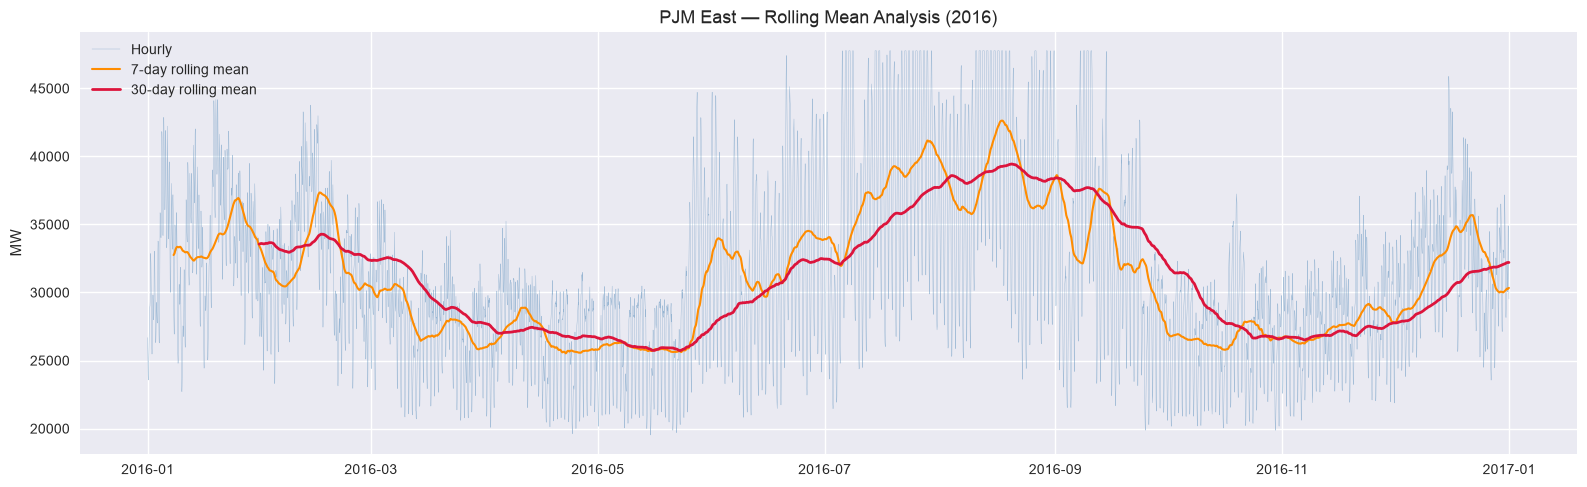

Avg peak-hour demand (08–20h) : 34,523.1 MW
Avg off-peak demand  (21–07h) : 29,013.4 MW
Peak vs off-peak gap          : 5,509.7 MW


In [7]:
pjm_2016 = pjm.loc['2016', 'PJME_MW']
roll7  = pjm_2016.rolling(168).mean()
roll30 = pjm_2016.rolling(720).mean()

plt.figure(figsize=(16, 5))
plt.plot(pjm_2016.index, pjm_2016.values, lw=0.3, color='steelblue', alpha=0.5, label='Hourly')
plt.plot(roll7.index,  roll7.values,  lw=1.5, color='darkorange', label='7-day rolling mean')
plt.plot(roll30.index, roll30.values, lw=2.0, color='crimson',    label='30-day rolling mean')
plt.title('PJM East — Rolling Mean Analysis (2016)', fontsize=13)
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_rolling.png'), bbox_inches='tight', dpi=120)
plt.show()

peak_mask = (pjm['hour'] >= 8) & (pjm['hour'] <= 20)
avg_peak    = pjm.loc[peak_mask,  'PJME_MW'].mean()
avg_offpeak = pjm.loc[~peak_mask, 'PJME_MW'].mean()
print(f'Avg peak-hour demand (08–20h) : {avg_peak:,.1f} MW')
print(f'Avg off-peak demand  (21–07h) : {avg_offpeak:,.1f} MW')
print(f'Peak vs off-peak gap          : {avg_peak - avg_offpeak:,.1f} MW')

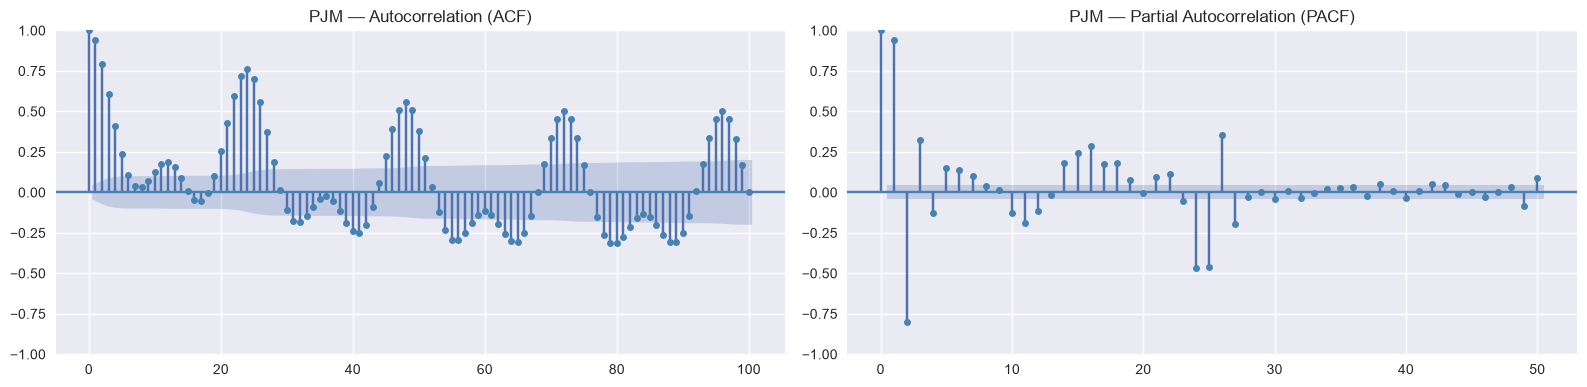

Strong autocorrelation spikes at lag=1 (1h), lag=24 (daily), lag=168 (weekly).
This confirms periodic seasonality — well-suited for LSTM/GRU models.


In [8]:
sample_pjm = pjm['PJME_MW'].iloc[:2016]   # 12 weeks

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( sample_pjm, lags=100, ax=axes[0], color='steelblue')
axes[0].set_title('PJM — Autocorrelation (ACF)', fontsize=12)

plot_pacf(sample_pjm, lags=50,  ax=axes[1], color='steelblue', method='ywm')
axes[1].set_title('PJM — Partial Autocorrelation (PACF)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_acf.png'), bbox_inches='tight', dpi=120)
plt.show()
print('Strong autocorrelation spikes at lag=1 (1h), lag=24 (daily), lag=168 (weekly).')
print('This confirms periodic seasonality — well-suited for LSTM/GRU models.')

---
## Part 2 — UCI Household Dataset

In [9]:
print('=== UCI Household — Basic Statistics ===\n')
print(uci[['Global_active_power']].describe().round(4).to_string())
print(f'\nDate range  : {uci.index.min().date()} to {uci.index.max().date()}')
print(f'Total hours : {len(uci):,}')
print(f'Columns     : {list(uci.columns)}')

=== UCI Household — Basic Statistics ===

       Global_active_power
count           34589.0000
mean                1.0758
std                 0.8517
min                 0.1240
25%                 0.3422
50%                 0.8049
75%                 1.5753
max                 3.4249

Date range  : 2006-12-16 to 2010-11-26
Total hours : 34,589
Columns     : ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'season', 'GAP_scaled']


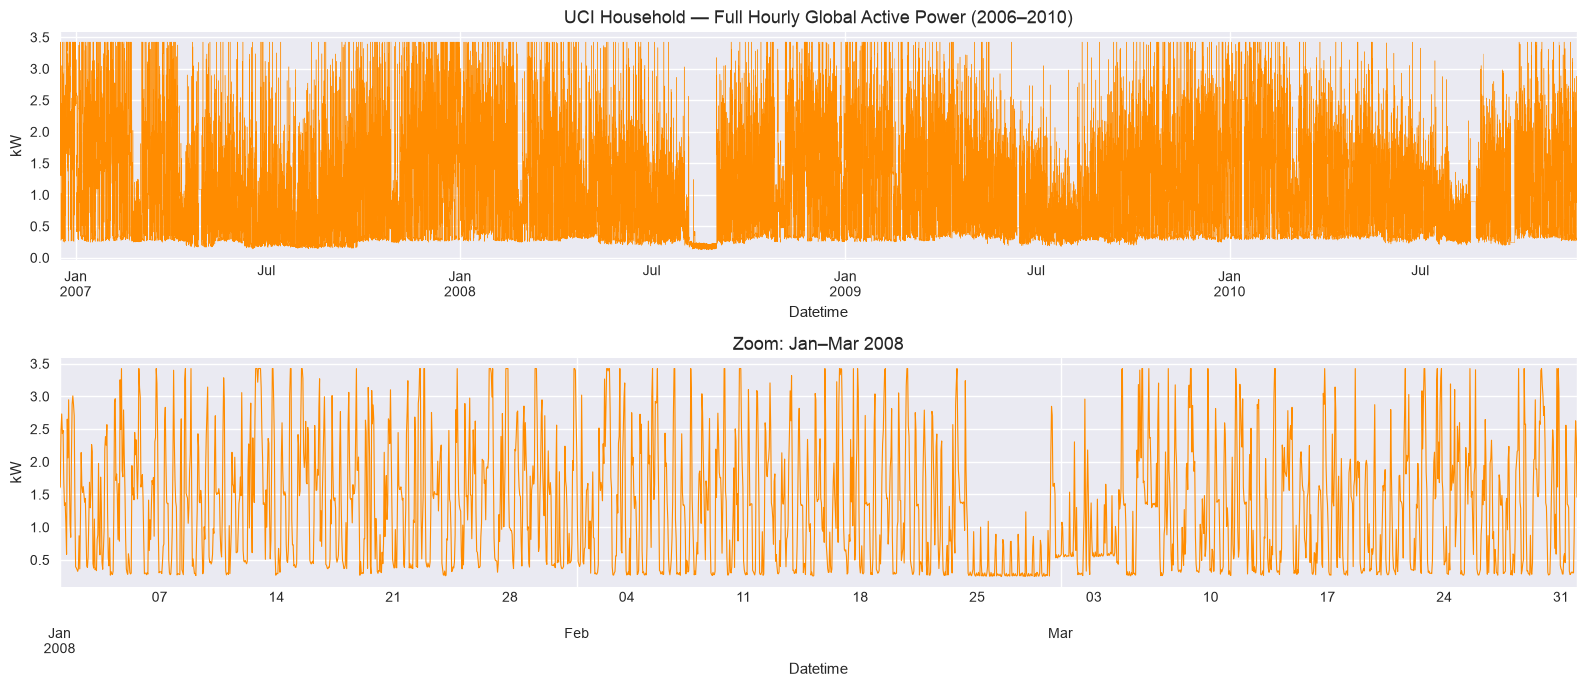

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7))

uci['Global_active_power'].plot(ax=axes[0], lw=0.3, color='darkorange')
axes[0].set_title('UCI Household — Full Hourly Global Active Power (2006–2010)', fontsize=13)
axes[0].set_ylabel('kW')

uci.loc['2008-01':'2008-03', 'Global_active_power'].plot(ax=axes[1], lw=0.8, color='darkorange')
axes[1].set_title('Zoom: Jan–Mar 2008', fontsize=13)
axes[1].set_ylabel('kW')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_timeseries.png'), bbox_inches='tight', dpi=120)
plt.show()

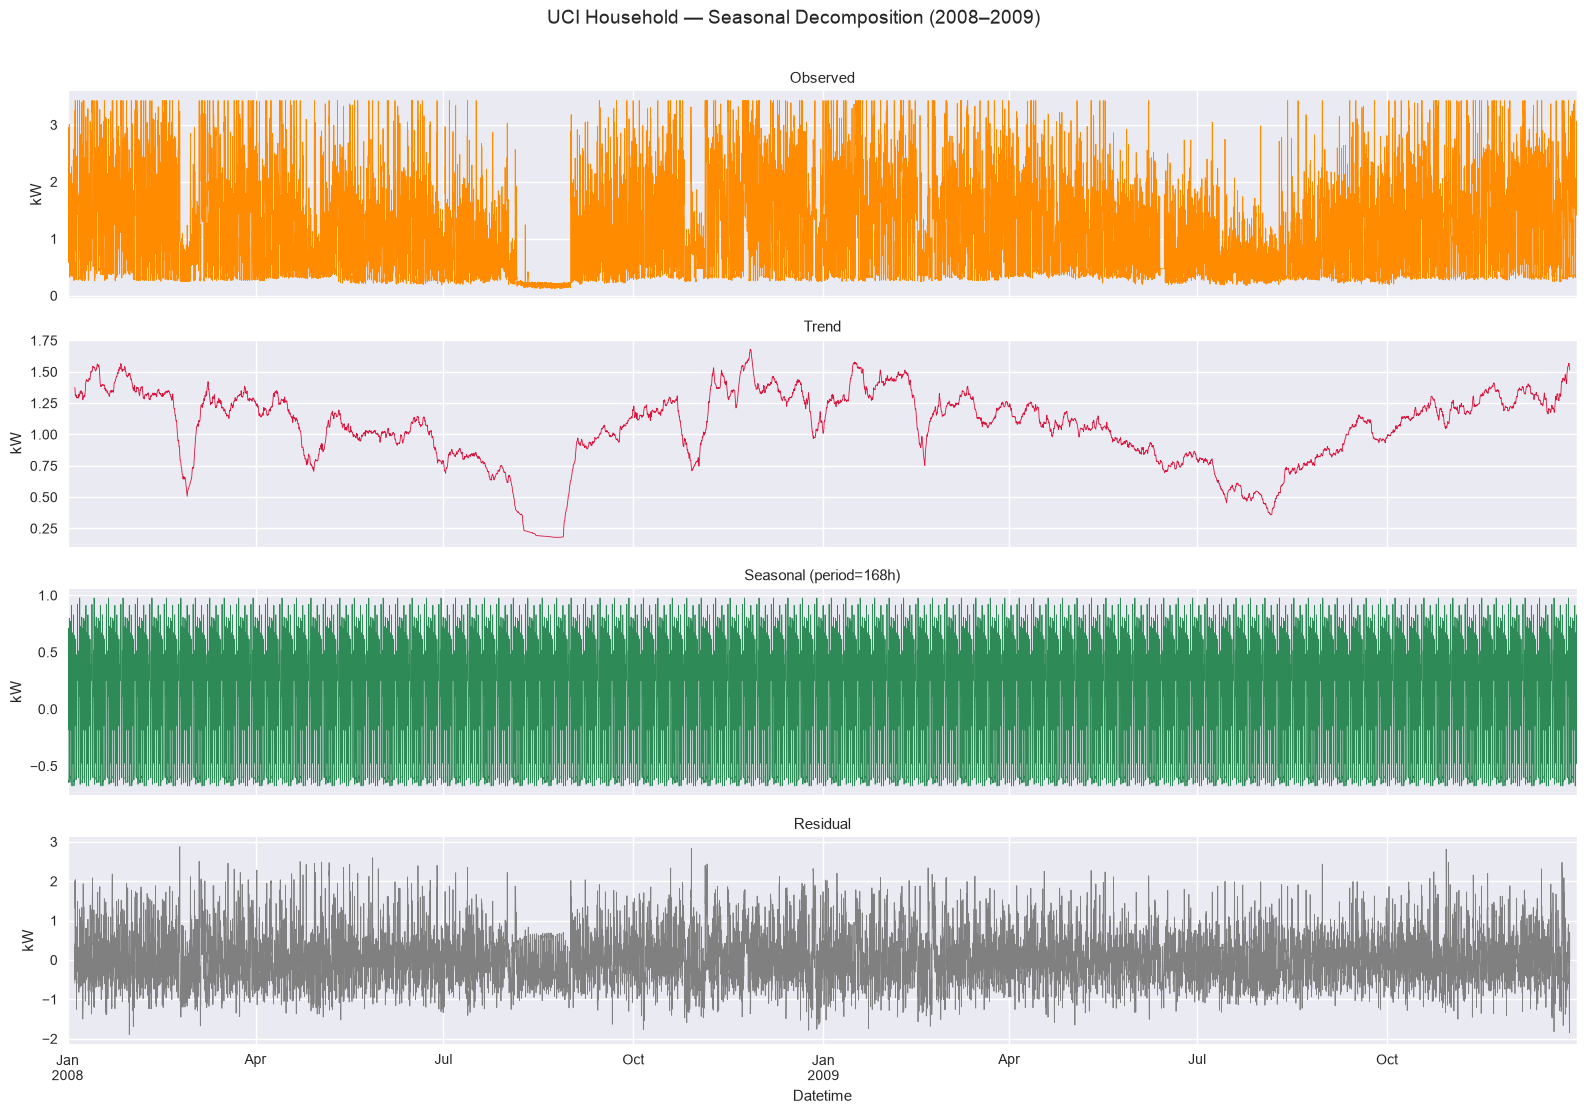

In [11]:
uci_sub  = uci.loc['2008':'2009', 'Global_active_power']
decomp_u = seasonal_decompose(uci_sub, model='additive', period=24 * 7)

fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
components = [
    (decomp_u.observed, 'Observed',              'darkorange'),
    (decomp_u.trend,    'Trend',                 'crimson'),
    (decomp_u.seasonal, 'Seasonal (period=168h)','seagreen'),
    (decomp_u.resid,    'Residual',              'gray'),
]
for ax, (series, title, colour) in zip(axes, components):
    series.plot(ax=ax, lw=0.6, color=colour)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('kW')

fig.suptitle('UCI Household — Seasonal Decomposition (2008–2009)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_decomposition.png'), bbox_inches='tight', dpi=120)
plt.show()

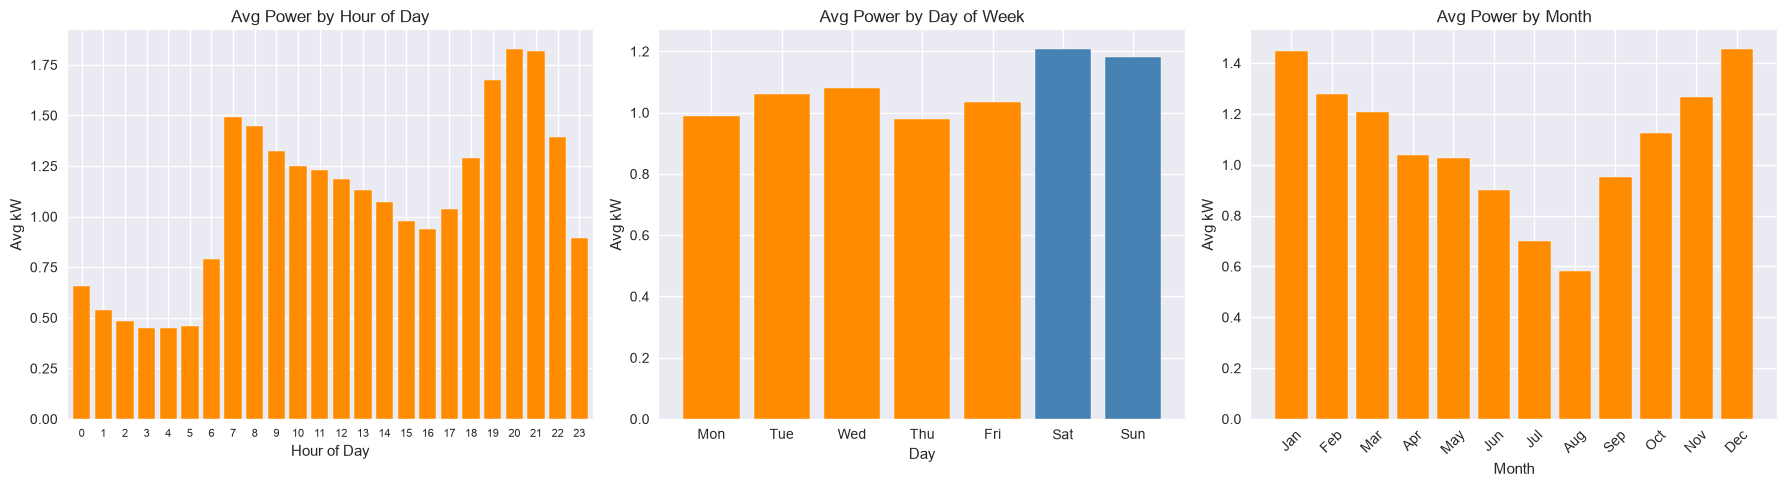


Average by season:
  Winter  : 1.3943 kW
  Spring  : 1.0909 kW
  Summer  : 0.7256 kW
  Autumn  : 1.1131 kW


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly_u = uci.groupby('hour')['Global_active_power'].mean()
hourly_u.plot(kind='bar', ax=axes[0], color='darkorange', edgecolor='white', width=0.8)
axes[0].set_title('Avg Power by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg kW')
axes[0].set_xticklabels(range(24), rotation=0, fontsize=8)

days   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_u = uci.groupby('day_of_week')['Global_active_power'].mean()
colours = ['darkorange'] * 5 + ['steelblue'] * 2
axes[1].bar(days, daily_u.values, color=colours, edgecolor='white')
axes[1].set_title('Avg Power by Day of Week', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg kW')

months   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_u = uci.groupby('month')['Global_active_power'].mean()
axes[2].bar([months[m-1] for m in monthly_u.index],
            monthly_u.values, color='darkorange', edgecolor='white')
axes[2].set_title('Avg Power by Month', fontsize=12)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg kW')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_patterns.png'), bbox_inches='tight', dpi=120)
plt.show()

seasons = {0:'Winter',1:'Spring',2:'Summer',3:'Autumn'}
print('\nAverage by season:')
for k, v in seasons.items():
    val = uci[uci['season'] == k]['Global_active_power'].mean()
    print(f'  {v:7s} : {val:.4f} kW')

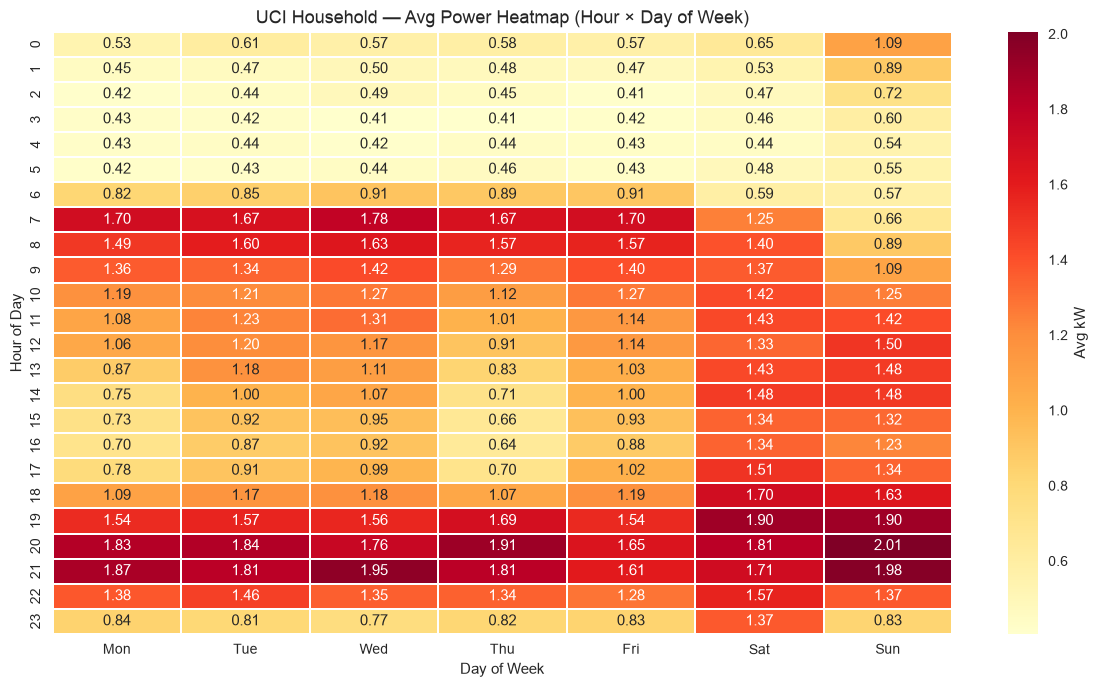

Peak avg power : 2.0059 kW  at 20:00 on Sun


In [13]:
pivot_u = uci.pivot_table(values='Global_active_power', index='hour',
                           columns='day_of_week', aggfunc='mean')
pivot_u.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_u, cmap='YlOrRd', linewidths=0.3,
            annot=True, fmt='.2f', cbar_kws={'label': 'Avg kW'})
plt.title('UCI Household — Avg Power Heatmap (Hour × Day of Week)', fontsize=13)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_heatmap.png'), bbox_inches='tight', dpi=120)
plt.show()

peak_u = pivot_u.stack().idxmax()
print(f'Peak avg power : {pivot_u.stack().max():.4f} kW  at {peak_u[0]:02d}:00 on {peak_u[1]}')

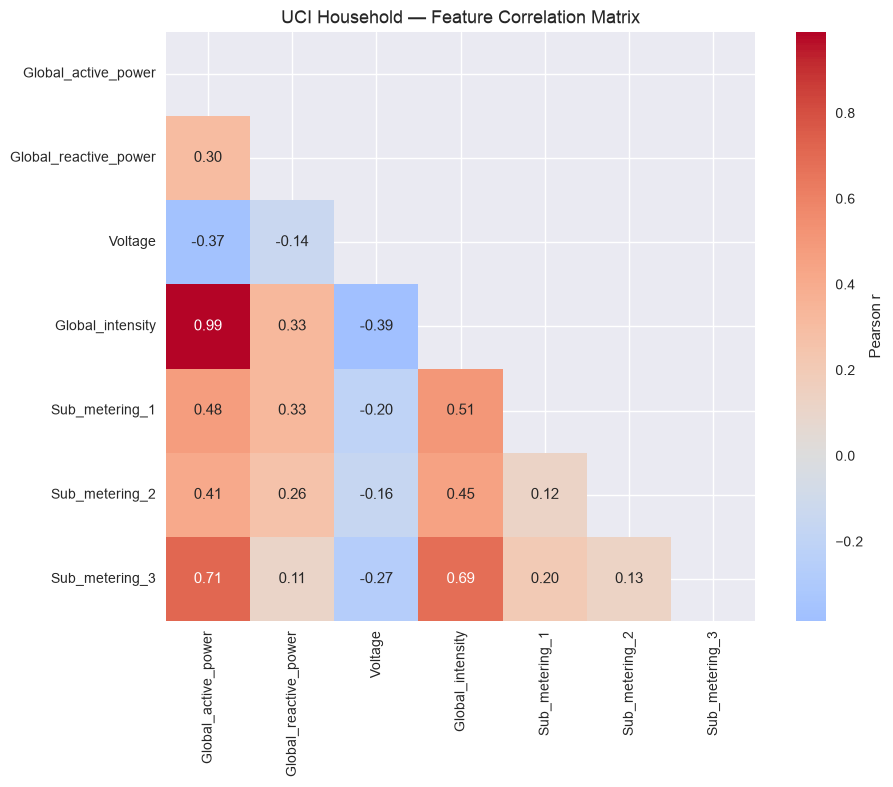


Correlations with Global_active_power (descending):
Global_intensity         0.990
Sub_metering_3           0.714
Sub_metering_1           0.478
Sub_metering_2           0.411
Global_reactive_power    0.303
Voltage                 -0.369


In [14]:
power_cols = ['Global_active_power','Global_reactive_power','Voltage',
              'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
available  = [c for c in power_cols if c in uci.columns]
corr = uci[available].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('UCI Household — Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_correlation.png'), bbox_inches='tight', dpi=120)
plt.show()

print('\nCorrelations with Global_active_power (descending):')
print(corr['Global_active_power'].drop('Global_active_power')
      .sort_values(ascending=False).round(3).to_string())

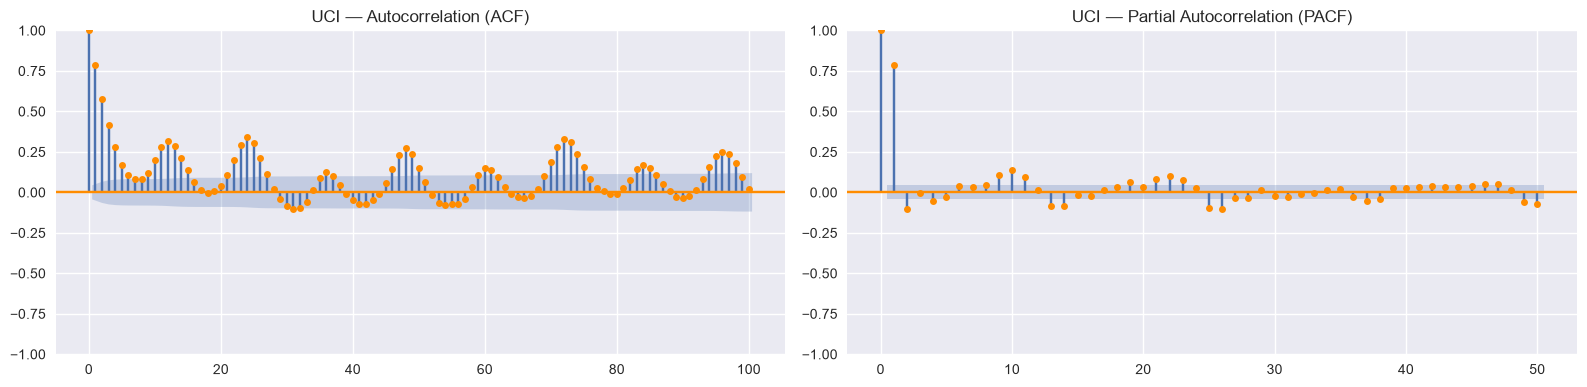

Daily (lag=24) and weekly (lag=168) autocorrelation spikes confirm strong seasonality.


In [15]:
sample_uci = uci['Global_active_power'].iloc[:2016]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( sample_uci, lags=100, ax=axes[0], color='darkorange')
axes[0].set_title('UCI — Autocorrelation (ACF)', fontsize=12)

plot_pacf(sample_uci, lags=50,  ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('UCI — Partial Autocorrelation (PACF)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_acf.png'), bbox_inches='tight', dpi=120)
plt.show()
print('Daily (lag=24) and weekly (lag=168) autocorrelation spikes confirm strong seasonality.')

---
## Key Findings Summary

### PJM East
| Finding | Value |
|---|---|
| Peak hour | ~18:00 weekdays |
| Lowest demand | 03:00–05:00 weekends |
| Highest season | Summer (cooling load) |
| Lowest season | Spring |
| ACF spikes | lag=1, lag=24 (daily), lag=168 (weekly) |

### UCI Household
| Finding | Value |
|---|---|
| Peak usage | Evening hours (19:00–21:00) |
| Weekend vs weekday | Weekend mornings show higher activity |
| Strongest correlation | Global_intensity ↔ Global_active_power (~0.99) |
| ACF spikes | lag=1, lag=24 (daily), lag=168 (weekly) |

**Modelling implication**: Strong periodicity at 24h and 168h confirms LSTM/GRU models with 24-hour look-back windows are appropriate. The CNN-LSTM hybrid can exploit local hourly patterns via convolution.